# 1. Train — simulated CRM data (`data/crm_simulated/`)

Same steps as `python -m src.train --data-dir data/crm_simulated`, one cell per step, using the functions in `src/train.py`.
Models are saved to `reports/crm/simulated/final/models/` for `2_evaluate.ipynb` and `3_predict.ipynb`. No test row is scored here.

Kernel: the project environment `.venv-crm` (Python 3.12).

The simulated data must exist in `data/crm_simulated/` (see `docs/SIMULATED_DATA.md` to regenerate it).
Results are never written to `reports/crm/final/`. A full run takes a few minutes (TabNet is the slowest).

In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "train.py").is_file())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from src import train


## Settings

In [2]:
DATA_DIR = ROOT / "data/crm_simulated"   # 100,000 simulated deals
QUICK = False            # True: tiny budgets, smoke test only (writes a *smoke* folder)
OUTPUT = train.default_output(DATA_DIR, QUICK)
print("Data:  ", DATA_DIR)
print("Output:", OUTPUT)

Data:   /Users/thaiphan/sources/miu/cs582-project/data/crm_simulated
Output: /Users/thaiphan/sources/miu/cs582-project/reports/crm/simulated/final


## 1. Load, validate and split the data

Joins the four CRM tables, builds the 18 pre-close features and splits closed deals by engagement date.
Training and validation keep only deals whose outcome was known before the next period.

In [3]:
out, manifest, dataset, split = train.start(OUTPUT, quick=QUICK, data_dir=DATA_DIR)
report = dataset.report
pd.Series({
    "closed deals (labeled)": report["rows"],
    "won": report["positives"],
    "lost": report["negatives"],
    "open deals": report["open_rows"],
    "scorable Engaging deals": report["scorable_open_rows"],
    "scorable deals missing an account": report["scorable_missing_account"],
    "features": len(dataset.feature_columns),
})

closed deals (labeled)               71463
won                                  44899
lost                                 26564
open deals                           28537
scorable Engaging deals              22810
scorable deals missing an account    15582
features                                18
dtype: int64

In [4]:
pd.DataFrame(manifest["split"], index=["value"]).T

,value
method,engagement date groups + outcome availability ...
validation_start,2017-07-17
test_start,2017-09-18
train_rows,32470
validation_rows,4920
test_rows,14322
purged_rows,19751
train_win_rate,0.622821
validation_win_rate,0.605488
test_win_rate,0.613252


## 2. Fit the five models

Each cell fits one model on the training rows, picks its class threshold on validation (macro-F1)
and shows its validation metrics.

In [5]:
fitted = {}
COLUMNS = ["model", "roc_auc", "accuracy", "precision", "recall", "f1", "brier", "threshold"]

def show(name):
    return pd.DataFrame([fitted[name][2]])[COLUMNS].round(4)

fitted["dummy_prior"] = train.fit_one("dummy_prior", dataset, split, quick=QUICK)
show("dummy_prior")

,model,roc_auc,accuracy,precision,recall,f1,brier,threshold
0,dummy_prior,0.5,0.6055,0.6055,1.0,0.7543,0.2392,0.5


In [6]:
fitted["logistic_regression"] = train.fit_one("logistic_regression", dataset, split, quick=QUICK)
show("logistic_regression")

,model,roc_auc,accuracy,precision,recall,f1,brier,threshold
0,logistic_regression,0.8042,0.7423,0.7949,0.7741,0.7844,0.1739,0.55


In [7]:
fitted["random_forest"] = train.fit_one("random_forest", dataset, split, quick=QUICK)
show("random_forest")

,model,roc_auc,accuracy,precision,recall,f1,brier,threshold
0,random_forest,0.8522,0.7858,0.8203,0.8275,0.8239,0.1499,0.57


In [8]:
fitted["mlp"] = train.fit_one("mlp", dataset, split, quick=QUICK)
show("mlp")

,model,roc_auc,accuracy,precision,recall,f1,brier,threshold
0,mlp,0.8522,0.7772,0.8483,0.7697,0.8071,0.1502,0.63


In [9]:
fitted["tabnet"] = train.fit_one("tabnet", dataset, split, quick=QUICK)
show("tabnet")


Early stopping occurred at epoch 45 with best_epoch = 33 and best_validation_auc = 0.85279


/Users/thaiphan/sources/miu/cs582-project/.venv-crm/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


,model,roc_auc,accuracy,precision,recall,f1,brier,threshold
0,tabnet,0.8528,0.7872,0.7963,0.8714,0.8322,0.1498,0.5


### Learning curves of the neural models

Early stopping keeps the epoch with the best validation ROC-AUC (dashed line).

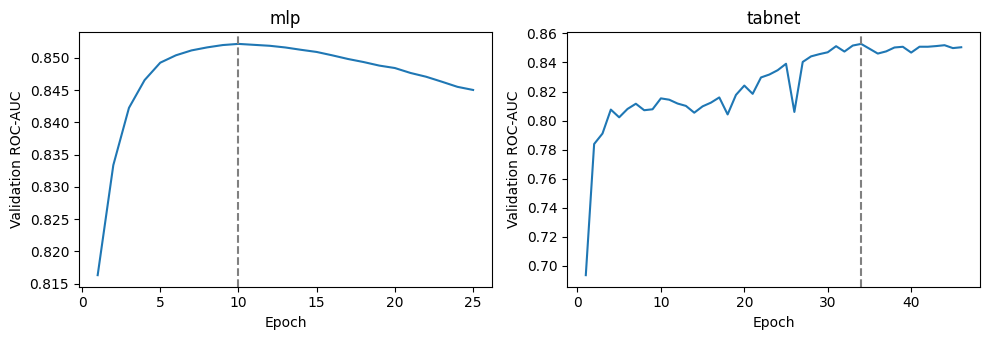

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, name in zip(axes, ["mlp", "tabnet"]):
    model = fitted[name][0]
    ax.plot(range(1, len(model.history["validation_auc"]) + 1), model.history["validation_auc"])
    ax.axvline(model.settings["best_epoch"], ls="--", color="gray")
    ax.set(title=name, xlabel="Epoch", ylabel="Validation ROC-AUC")
plt.tight_layout()

## 3. Compare on validation, select, calibrate and save

The model with the highest validation ROC-AUC is selected (ties: lower Brier, then name).
A sigmoid calibration is fitted on validation around the frozen selected model.

In [11]:
pd.DataFrame([f[2] for f in fitted.values()])[COLUMNS].sort_values("roc_auc", ascending=False).round(4)

,model,roc_auc,accuracy,precision,recall,f1,brier,threshold
4,tabnet,0.8528,0.7872,0.7963,0.8714,0.8322,0.1498,0.50
2,random_forest,0.8522,0.7858,0.8203,0.8275,0.8239,0.1499,0.57
3,mlp,0.8522,0.7772,0.8483,0.7697,0.8071,0.1502,0.63
1,logistic_regression,0.8042,0.7423,0.7949,0.7741,0.7844,0.1739,0.55
0,dummy_prior,0.5000,0.6055,0.6055,1.0000,0.7543,0.2392,0.50


In [12]:
trained = train.finish(out, manifest, dataset, split, fitted)
print("Selected:", trained.selected)
print("Raw threshold:", trained.thresholds[trained.selected], "-> calibrated:", round(trained.decision_threshold, 4))
print("Calibration slope / intercept:", round(trained.calibrated.slope, 4), round(trained.calibrated.intercept, 4))
sorted(p.name for p in out.models.iterdir())

TRAINED: selected=tabnet; models saved in /Users/thaiphan/sources/miu/cs582-project/reports/crm/simulated/final/models
Selected: tabnet
Raw threshold: 0.5 -> calibrated: 0.4872
Calibration slope / intercept: 1.0543 -0.0512


['explanation_reference.json',
 'model_bundle.joblib',
 'model_training.json',
 'trained_models.joblib']

Next: `2_evaluate.ipynb` for test metrics, then `3_predict.ipynb` for scores.